<a href="https://colab.research.google.com/github/ranjanrashika/-Hi-I-am-/blob/main/Multi_Agent_Governance_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
policy_text = "Deploy AI-based facial recognition surveillance in cities for public safety."

print("Policy Loaded:")
print(policy_text)

Policy Loaded:
Deploy AI-based facial recognition surveillance in cities for public safety.


In [2]:
def legal_agent(policy):
  print("Legal Agent analyzing...")

  if "surveillance" in policy.lower():
    risk_score = 85
  else:
    risk_score = 20
  return {
      "agent": "Legal",
      "risk_score": risk_score,
      "confidence": 0.9
  }
legal_result = legal_agent(policy_text)
legal_result

Legal Agent analyzing...


{'agent': 'Legal', 'risk_score': 85, 'confidence': 0.9}

In [3]:
def ethics_agent(policy):
  print("Ethics Agent analysing...")
  if "facial recognition" in policy.lower():
    risk_score = 90
  else:
    risk_score = 30

  return {
      "agent": "Ethics",
      "risk_score": risk_score,
      "confidence": 0.95
  }
ethics_result = ethics_agent(policy_text)
ethics_result

Ethics Agent analysing...


{'agent': 'Ethics', 'risk_score': 90, 'confidence': 0.95}

In [4]:
def risk_agent(policy):
  print("Risk Agent analysing...")
  if "ai" in policy.lower():
    risk_score = 70
  else:
    risk_score = 70
  return {
      "agent": "Impact",
      "risk_score": risk_score,
      "confidence": 0.85
  }
risk_result = risk_agent(policy_text)
risk_result

Risk Agent analysing...


{'agent': 'Impact', 'risk_score': 70, 'confidence': 0.85}

In [5]:
agent_outputs = {
    "legal": legal_result,
    "ethics": ethics_result,
    "impact": risk_result
}

In [7]:
def decision_agent(outputs):
  total_score = 0
  weights ={
      "legal": 0.4,
      "ethics": 0.4,
      "impact": 0.2
  }

  for key in outputs:
    score = outputs[key]["risk_score"]
    confidence = outputs[key]["cofidence"]
    weighted_score = score*confidence*weights[key]
    total_score += weighted_score
  print("Final Rsik Score:", round(total_score, 2))

  if total_score > 75:
    return "REJECT POLICY"
  elif total_score > 45:
    return "MODIFY POLICY"
  else:
    return "APPROVE POLICY"
  decision = decision_agent(agents_outputs)
  decision

In [8]:
def devils_advocate_agent(policy):
  print("Devil's Advocate analysing...")

  if "facial recognition" in policy.lower():
    risk_score = 95
  elif "ai" in policy.lower():
    risk_score = 75
  else:
    risk_score = 30

  return {
      "agent": "Security",
      "risk_score": risk_score,
      "confidence": 0.9
  }
attack_result = devils_advocate_agent(policy_text)
attack_result

Devil's Advocate analysing...


{'agent': 'Security', 'risk_score': 95, 'confidence': 0.9}

In [9]:
agent_outputs = {
    "legal": legal_result,
    "ethics": ethics_result,
    "impact": risk_result,
    "security": attack_result
}
agent_outputs

{'legal': {'agent': 'Legal', 'risk_score': 85, 'confidence': 0.9},
 'ethics': {'agent': 'Ethics', 'risk_score': 90, 'confidence': 0.95},
 'impact': {'agent': 'Impact', 'risk_score': 70, 'confidence': 0.85},
 'security': {'agent': 'Security', 'risk_score': 95, 'confidence': 0.9}}

In [11]:
def decision_agent(outputs):
  weights = {
      "legal": 0.35,
      "ethics": 0.35,
      "impact": 0.15,
      "security": 0.15
  }
  total_score = 0
  print("\n--- Risk Breakdown ---")

  for key in outputs:
    score = outputs[key]["risk_score"]
    confidence = outputs[key]["confidence"]
    weighted_score = score*confidence*weights[key]
    total_score += weighted_score

    print(f"{key.capitalize()} Risk: {score} | Confidence: {confidence}")
  print("\nFinal Risk Score:", round(total_score, 2))

  if total_score > 75:
    decision = "REJECT POLICY"
  elif total_score > 45:
    decision = "MODIFY POLICY"
  else:
    decision = "APPROVE POLICY"
  return decision

decision = decision_agent(agent_outputs)
decision


--- Risk Breakdown ---
Legal Risk: 85 | Confidence: 0.9
Ethics Risk: 90 | Confidence: 0.95
Impact Risk: 70 | Confidence: 0.85
Security Risk: 95 | Confidence: 0.9

Final Risk Score: 78.45


'REJECT POLICY'

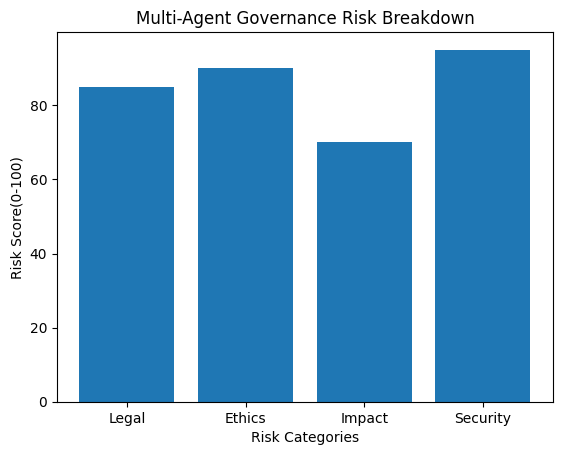

In [13]:
import matplotlib.pyplot as plt

categories = []
scores = []
for key in agent_outputs:
  categories.append(key.capitalize())
  scores.append(agent_outputs[key]["risk_score"])

plt.figure()
plt.bar(categories, scores)
plt.xlabel("Risk Categories")
plt.ylabel("Risk Score(0-100)")
plt.title("Multi-Agent Governance Risk Breakdown")
plt.show()